In [1]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.plots import plot_uncertainty_distributions, plot_combined_uncertainty_analysis
from lib.utils import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""

dataset = 'adni'
analysis_name = 'mci_ad_conversion'
outcome_name = 'label_36m'
build_ensemble_csv(analysis_name, outcome_name, index_col=['subject_id','month'])


all_patients = pd.read_csv(f'../data/{dataset}/adni_rolling_locf_36m.csv')



# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.set_index(['subject_id', 'month'], inplace=True)



# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats.index)


all_patients.set_index(['subject_id', 'month'], inplace=True)

Successfully aggregated 38234 predictions across 876 unique patients.


## Uncertainty Decomposition

Baseline entropy: 0.9299049601679836


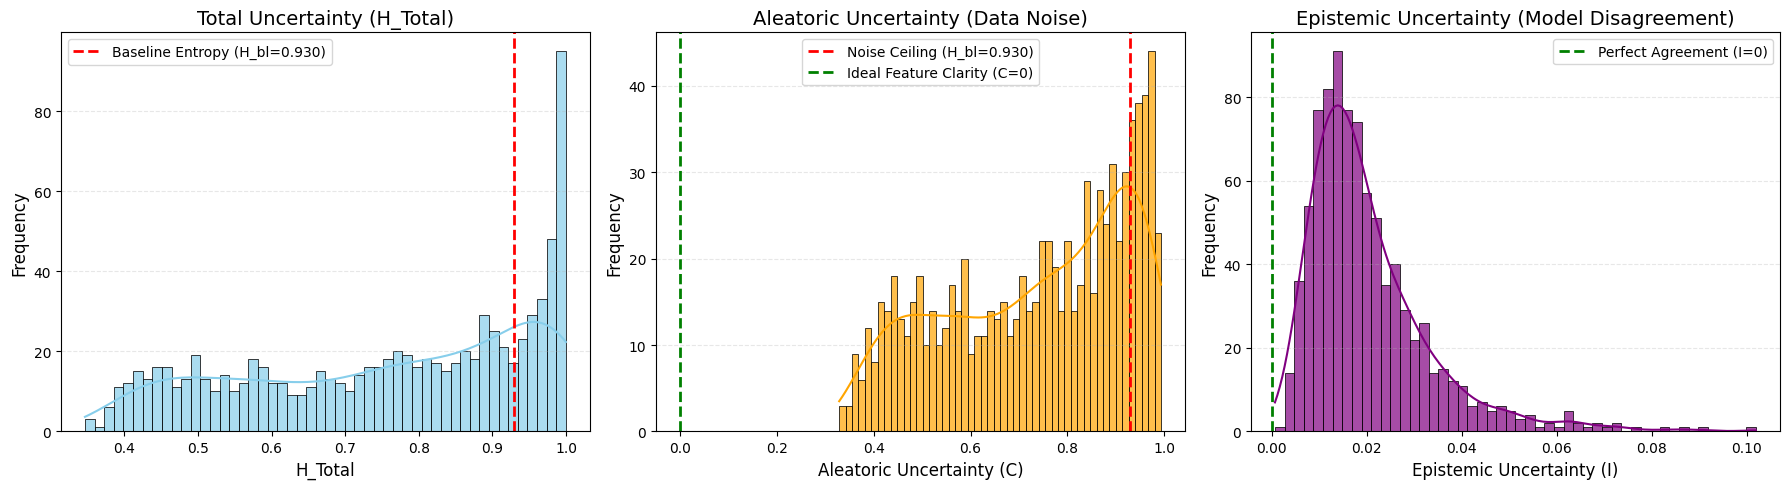

In [2]:
# Compute uncertainties for the non-active patients at baseline


uncertainty_results = compute_uncertainties(probs_raw_df)

# Create an explicit copy to avoid SettingWithCopyWarning
patients_stats_copy = patients_stats.copy()

# 2. Add the results to your main stats table
patients_stats_copy['H_Total'] = uncertainty_results['H_Total']
patients_stats_copy['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
patients_stats_copy['I_Epistemic'] = uncertainty_results['I_Epistemic']


# Compute the baseline risk (mean of probs_cal across all folds) for each patient and its uncertainty value 
proportion_positive = all_patients['label'].sum() / len(all_patients)
H_bl = -(proportion_positive * np.log2(proportion_positive + 1e-12) +
         (1 - proportion_positive) * np.log2(1 - proportion_positive + 1e-12))
print("Baseline entropy:", H_bl)



plot_uncertainty_distributions(
     patients_stats_copy, 
     H_bl, 
     #save_path='../results/uncertainty/plots/uncertainty_distributions.png'
 )

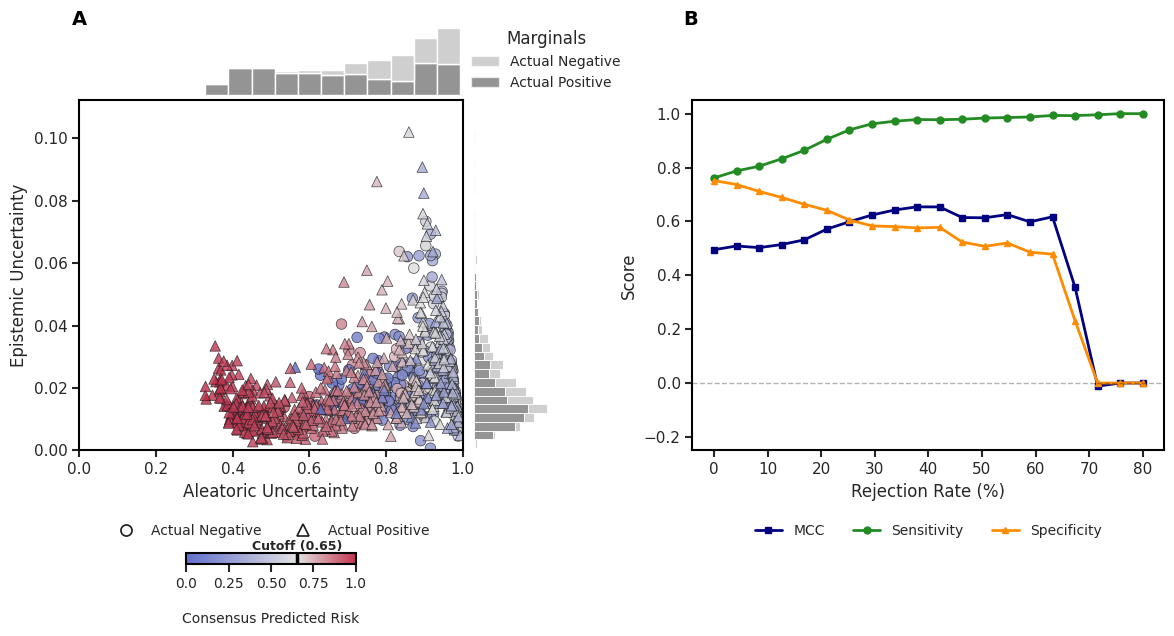

In [3]:
from lib.plots import plot_combined_uncertainty_analysis_v2


plot_combined_uncertainty_analysis_v2(patients_stats_copy,all_patients['label'])

## Run uncertainty on only baseline patients
Here we extract the uncertainty values for only the baseline patients and then plot the class-conditioned rejection curves. At this point we have to decide whether the task is "baseline visit screening" or "monitoring disease progression". If the former, then we should only consider the baseline patients for the uncertainty analysis. If the latter, then we should consider all augmented visits for the uncertainty analysis.

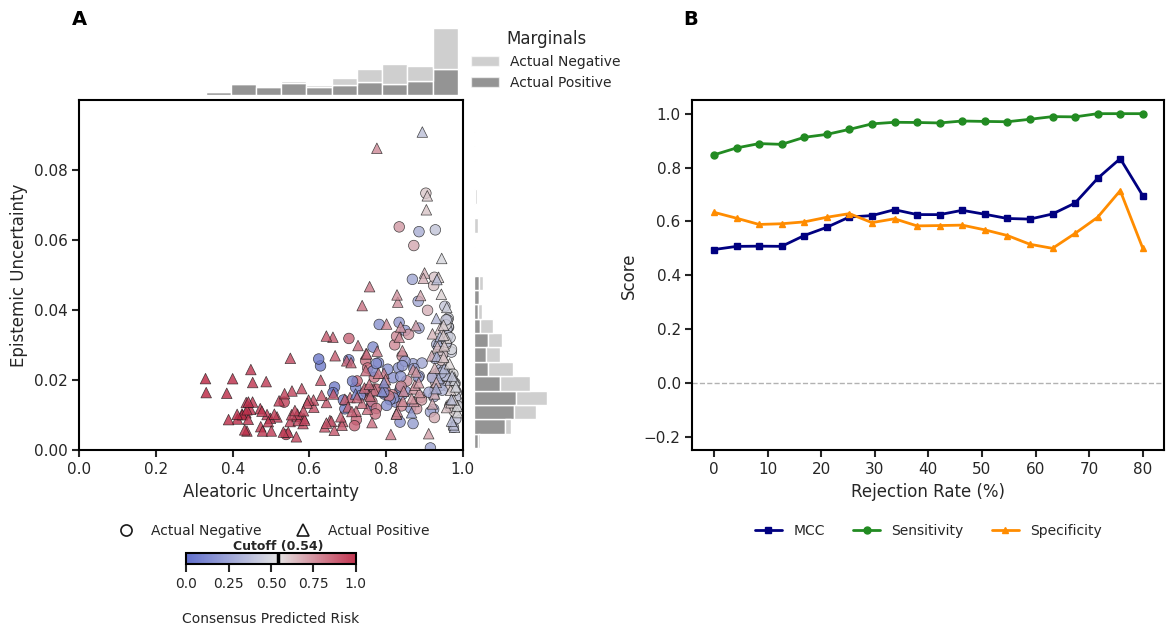

In [ ]:
from lib.plots import plot_combined_uncertainty_analysis_v2

patients_stats_bl = patients_stats_copy.xs(0, level='month', drop_level=False).copy()
all_patients_bl = all_patients.xs(0, level='month', drop_level=False).copy()

plot_combined_uncertainty_analysis_v2(patients_stats_bl, all_patients_bl['label'])

## Explore clinical data through GMM analysis
No clear separation between patients. The two scores do not agree on the number of clusters. For this MS dataset we are going to skip the GMM analysis and rejection and move on to Conditioned Classification Rejection Curves (CCRC).

Number of original clinical features: 11
Optimal PCs according to the Kaiser Rule: 5

Top 5 Eigenvalues:
[2.46 1.88 1.32 1.03 1.01]


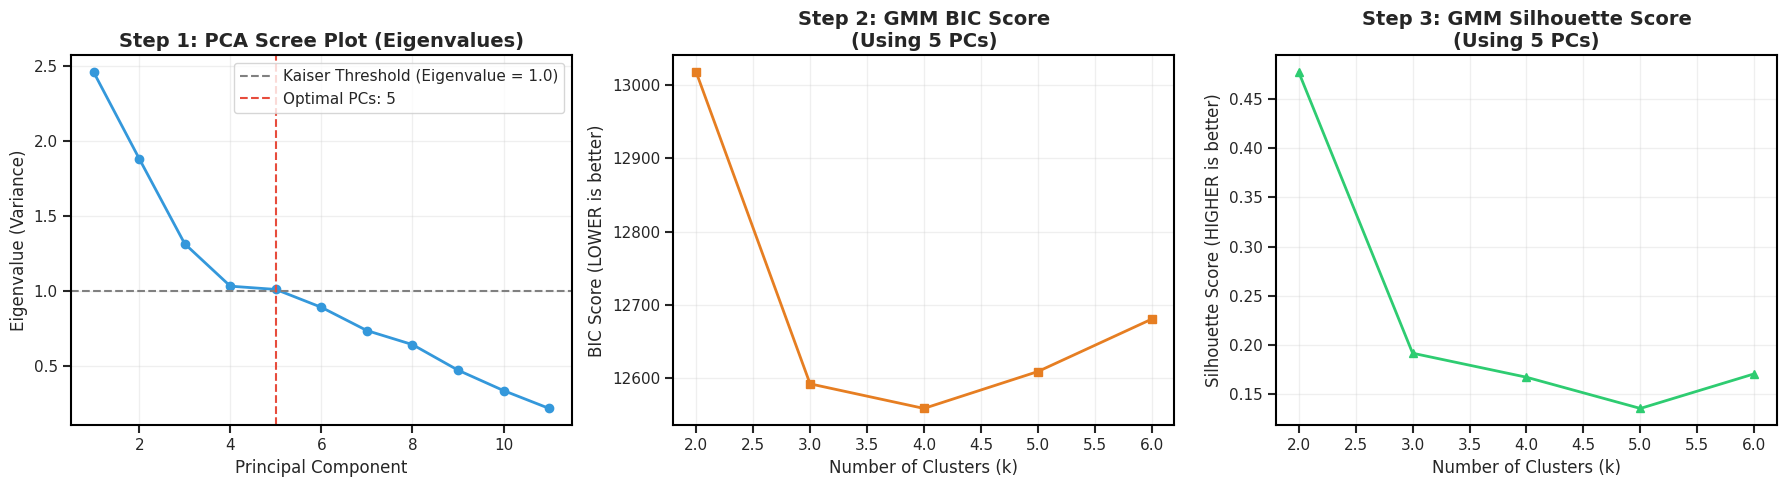


--- Optimization Results ---
1. Optimal PCs retained (Kaiser Rule, Eigenvalue > 1.0): 5
2. Best GMM model according to BIC (lowest complexity penalty): k = 4
3. Best GMM model according to Silhouette (highest separation): k = 2


In [6]:
from lib.clustering import optimize_pca_and_gmm_kaiser


optimize_pca_and_gmm_kaiser(X_clinical = all_patients.drop(['label'], axis=1), max_clusters=6)

## Conditioned Classification Rejection Curves (CCRC)

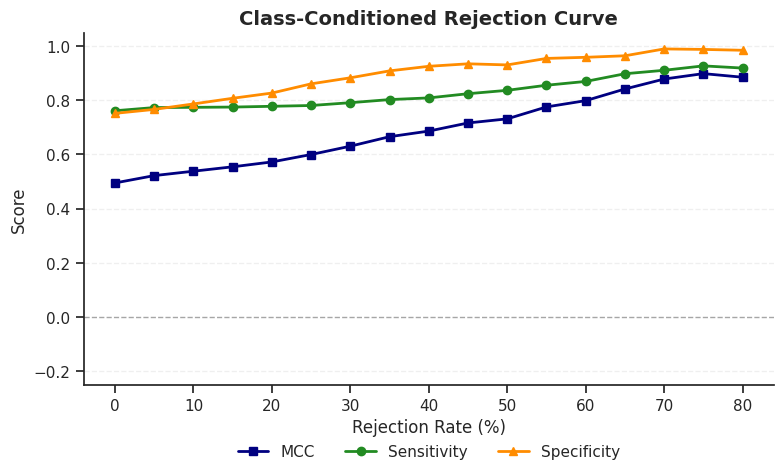

GLOBAL CLASS-CONDITIONED REJECTION: METRICS EVOLUTION
 Rejection (%)  Total Kept  TP  FP  TN  FN   MCC  Sensitivity  Specificity
             0         876 437  75 227 137 0.495        0.761        0.752
             5         833 419  68 223 123 0.522        0.773        0.766
            10         789 404  57 210 118 0.538        0.774        0.787
            15         746 389  47 197 113 0.554        0.775        0.807
            20         702 371  39 186 106 0.572        0.778        0.827
            25         657 356  28 173 100 0.600        0.781        0.861
            30         614 337  22 166  89 0.630        0.791        0.883
            35         570 317  16 159  78 0.666        0.803        0.909
            40         527 296  12 149  70 0.686        0.809        0.925
            45         483 272  10 143  58 0.716        0.824        0.935
            50         438 246  10 134  48 0.731        0.837        0.931
            55         395 225   6 126  38 0.7

In [15]:
from lib.plots import plot_class_conditioned_rejection_curve


optimal_threshold = all_patients['label'].mean()

class_cond_results = plot_class_conditioned_rejection_curve(
    patients_stats_copy, 
    threshold=optimal_threshold, 
    uncertainty_col='H_Total',
    rates=np.linspace(0, 80, 17)
)

### Confusion matrix evolution analysis


Standard global rejection frameworks fail in clinical datasets because predicting the onset of a future disease (Class 1) is inherently noisier than diagnosing baseline stability (Class 0). This Asymmetric Aleatoric Uncertainty causes standard algorithms to disproportionately delete the positive class, crashing the Sensitivity to zero.

By implementing Class-Conditioned Rejection tied to the baseline prior, we successfully decoupled the rejection threshold from this asymmetric noise.

Dataset 1 (The Imbalanced Cohort | Prior ~0.11) -> The "Rescue" Mechanism

Observation: The baseline model struggles with the rare minority class (Sens: ~0.69, MCC: 0.27).

Impact: Class-Conditioned Rejection actively rescues the model. By dropping the top 25% of uncertain patients proportionally from both predicted classes, Sensitivity actually rises to ~0.76 and holds steady. We successfully deferred a quarter of the most ambiguous patients without artificially collapsing the rare disease class.

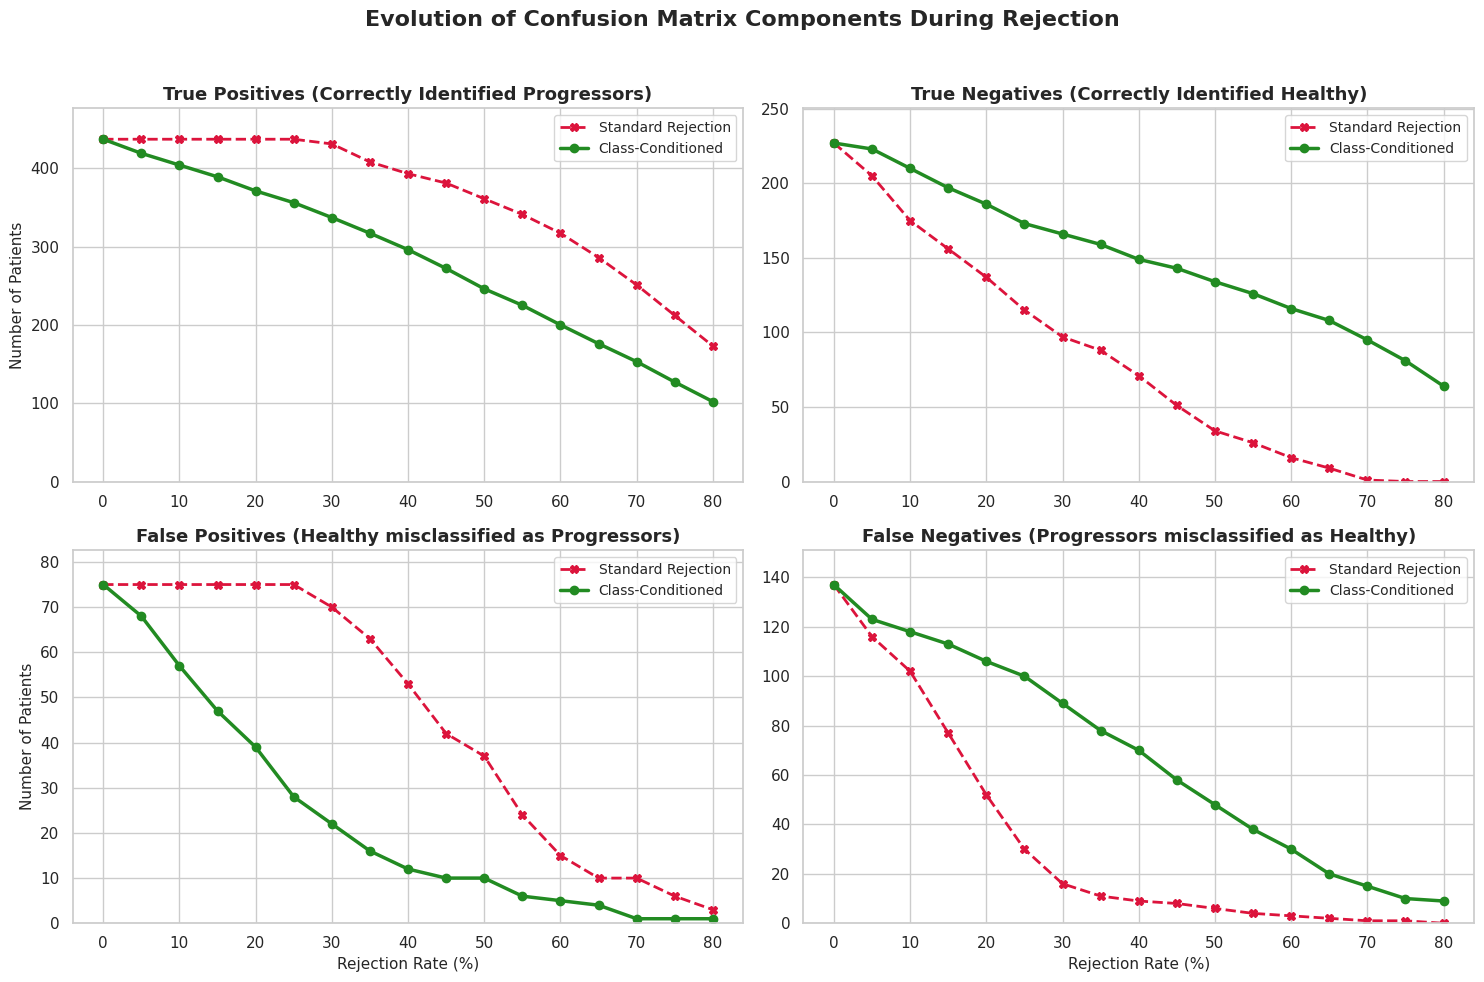

In [8]:
from lib.plots import plot_comprehensive_rejection_dashboard


optimal_threshold = patients_stats_copy['label'].mean()
dashboard_results = plot_comprehensive_rejection_dashboard(patients_stats_copy, threshold=optimal_threshold)

In [9]:

from lib.utils import extract_and_analyze_rejection


optimal_threshold = patients_stats_copy['label'].mean()

# Extract the patients at a 25% rejection rate
kept_df, removed_df, uncertainty_stats = extract_and_analyze_rejection(
     patients_stats_copy, 
     prior_threshold=optimal_threshold, 
     rate=25, 
     method='class_conditioned',
     sort_col='H_Total',
     uncertainty_cols=['H_Total', 'C_Aleatoric', 'I_Epistemic', 'sigma']
)

REJECTION AUDIT: CLASS_CONDITIONED @ 25%
Total Cohort:    876 patients
Total Kept:      657 patients
Total Removed:   219 patients
--------------------------------------------------------------------------------
UNCERTAINTY PROFILE COMPARISON:
     Metric  Kept_Profile Removed_Profile P_Value
    H_Total 0.706 ± 0.194   0.915 ± 0.076  <0.001
C_Aleatoric 0.687 ± 0.188   0.890 ± 0.075  <0.001
I_Epistemic 0.019 ± 0.013   0.025 ± 0.013  <0.001
      sigma 0.063 ± 0.028   0.085 ± 0.023  <0.001


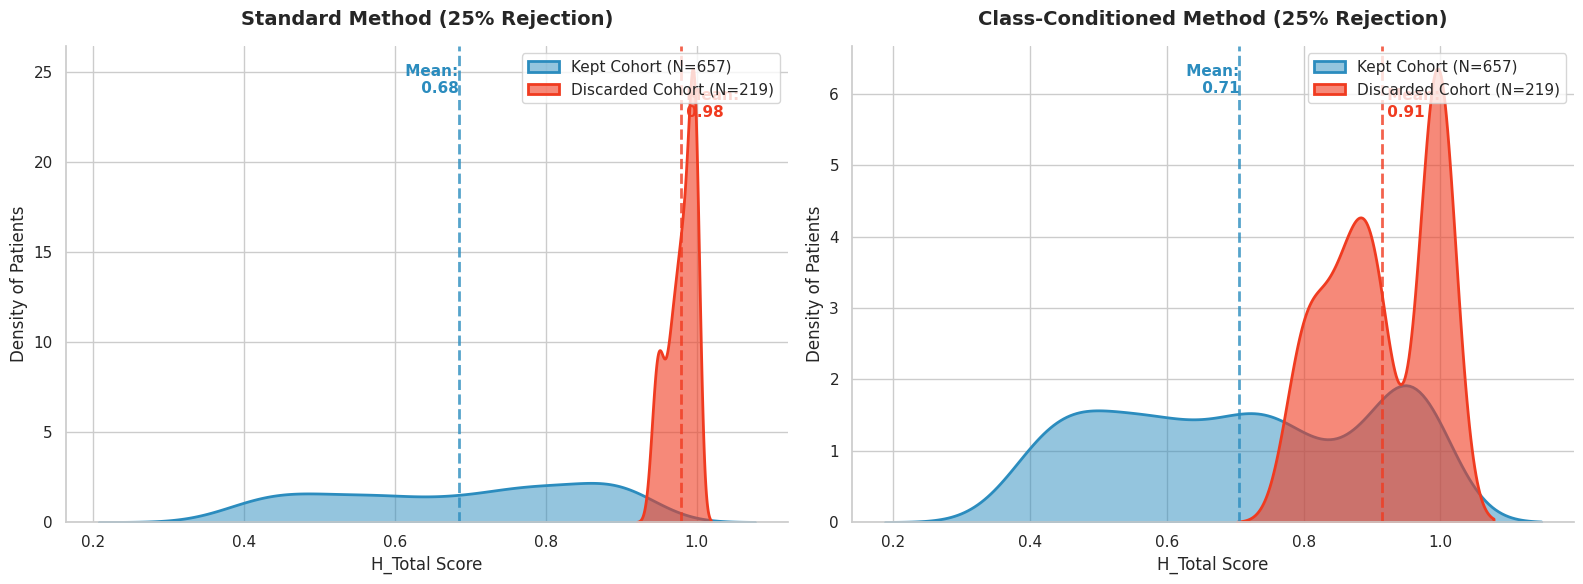

In [10]:


from lib.plots import plot_side_by_side_distributions


# --- Example Usage ---
optimal_threshold = patients_stats_copy['label'].mean()
plot_side_by_side_distributions(patients_stats_copy, threshold=optimal_threshold, rate=25)

1. The Left Plot: The "Blind Guillotine"
Look at the Standard Method on the left. There is a rigid, vertical invisible wall right around H_Total = 0.55.

The algorithm blindly looked at the dataset, drew a line, and chopped off everything to the right.

As we established, the minority class (Progressors) naturally lives on the right side of this chart because their disease is biologically harder to predict. By dropping the guillotine here, the standard method is just indiscriminately wiping out your True Positives.

2. The Right Plot: The "Intelligent Scalpel" (The Breakthrough)
This plot is everything you want to see. Look at the massive structural changes:

The Red Peak shifted LEFT: In the standard method, discarded patients averaged 0.74. Here, there is a massive red spike of discarded patients sitting all the way down at ~0.45. What is the algorithm doing? It is looking at the Majority Class (Healthy) and saying: "You are supposed to be easy to predict. An uncertainty of 0.45 is suspiciously high for a healthy patient. You are discarded." It is actively cleaning out the noisy False Positives!

The Blue Tail shifted RIGHT: Look at the blue curve (Kept Cohort). It now has a secondary hump stretching all the way past 0.8! What is the algorithm doing here? It is looking at the Minority Class (Progressors) and saying: "You have an uncertainty of 0.75, which is high, but predicting the future is hard. Compared to your peers, you are actually one of our best positive predictions. You are kept." ### The Verdict
You have visually proven that your Class-Conditioned method protects the minority class. By allowing the distributions to overlap, you demonstrated that absolute uncertainty is not a fair metric for rejection in imbalanced clinical data. You have to judge a prediction's uncertainty relative to the baseline difficulty of its class.